In [ ]:
#| default_exp clustering_ex

In [ ]:
#| hide
import plotly.io as pio

In [ ]:
#| hide
pio.renderers.default = "png"

# Clustering of Embeddings
> Clustering is a dedicated module‑level example. It builds on top of classification, since clusters are often defined using classifier‑based similarity measures, such as those induced by KNN. Clustering is useful as a similarity summary across multiple time series, providing a compact view of how signals group together based on their temporal or embedding‑level characteristics.

> By integrating clustering with embeddings, users can observe how different representation choices influence the resulting cluster structure. This makes clustering a practical tool for diagnosing embedding quality, comparing feature‑extraction strategies, and gaining intuition about the underlying variability in a time‑series collection.

In [ ]:
#| eval: false

from fhemb.utils.cutils import plot_dm_dendrogram, plot_clustered_dm_heatmap, dtw_clustering, depict_clusters, compute_silhouette_vs_k, plot_silhouette_curves

/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
DEBUG:fhemb.config.settings:Loading environment from /Users/radned/.config/fhemb/.env.paths
DEBUG:fhemb.config.settings:Loading environment from /Users/radned/.config/fhemb/.env.db
 [DEBUG] cutils.<module>: ROOT: /Users/radned/Projects/ttsembedding/


In [ ]:
#| eval: false

from nbdev_fhemb.wreconstruction_ex import emb_prj_decomp_rec1

 [DEBUG] mixins.wrapper: wrapper of process_subjects called with subjs=[(40, 44), (47, 52), 53, 54, (56, 71), (73, 75)], args=() and kwargs={'title': 'Don Giovanni', 'time_interval': (14200, 15200)}
 [DEBUG] mixins.wrapper: Calling: get_piece_attribute_values with title=Don Giovanni and atributes=['number_of_subjects']
 [DEBUG] mixins.wrapper: to get subjects_int from 'number_of_subjects' record in performance_library
 [DEBUG] mixins.wrapper: Calling: __init__ with subjs=[40, 41, 42, 43, 44, 47, 48, 49, 50, 51, 52, 53, 54, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 73, 74, 75] and args=() and kwargs={'title': 'Don Giovanni', 'time_interval': (14200, 15200)}
 [DEBUG] piece.__init__: Processed subjects: [40, 41, 42, 43, 44, 47, 48, 49, 50, 51, 52, 53, 54, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 73, 74, 75]
 [DEBUG] piece.__init__: Compact numeric subjects: [(40, 44), (47, 54), (56, 71), (73, 75)]
 [INFO] piece._load_from_db: Loading face_t fro

In [ ]:
#| eval: false
from nbdev_fhemb.module_functions_ex import Xdm

 [DEBUG] mixins.wrapper: wrapper of process_subjects called with subjs=[(40, 44), (47, 52), 53, 54, (56, 71), (73, 75)], args=() and kwargs={'title': 'Don Giovanni', 'time_interval': (14200, 15200)}
 [DEBUG] mixins.wrapper: Calling: get_piece_attribute_values with title=Don Giovanni and atributes=['number_of_subjects']
 [DEBUG] mixins.wrapper: to get subjects_int from 'number_of_subjects' record in performance_library
 [DEBUG] mixins.wrapper: Calling: __init__ with subjs=[40, 41, 42, 43, 44, 47, 48, 49, 50, 51, 52, 53, 54, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 73, 74, 75] and args=() and kwargs={'title': 'Don Giovanni', 'time_interval': (14200, 15200)}
 [DEBUG] piece.__init__: Processed subjects: [40, 41, 42, 43, 44, 47, 48, 49, 50, 51, 52, 53, 54, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 73, 74, 75]
 [DEBUG] piece.__init__: Compact numeric subjects: [(40, 44), (47, 54), (56, 71), (73, 75)]
 [INFO] piece._load_from_db: Loading face_t fro

## Cluster DTW Alignments Between Pairs of Embeddings

In [ ]:
#| eval: false
from scipy.spatial.distance import (
    euclidean, 
    cityblock, 
    cosine, 
    mahalanobis, 
    sqeuclidean, 
    chebyshev, 
    minkowski, 
    braycurtis, 
    canberra, 
    correlation, 
    jaccard, 
    hamming
)

### Clustered heatmap
> pairwise distances whose rows and columns are reordered using hierarchical clustering, revealing similarity structure among the time series.

 [INFO] cutils.calc_dtw_dmatrix: Using cosine distance
 [DEBUG] cutils.calc_distance_matrix: Computing DTW distance matrix for symmetric data
Computing DTW distances: 100%|██████████| 2080/2080 [04:34<00:00,  7.57it/s]


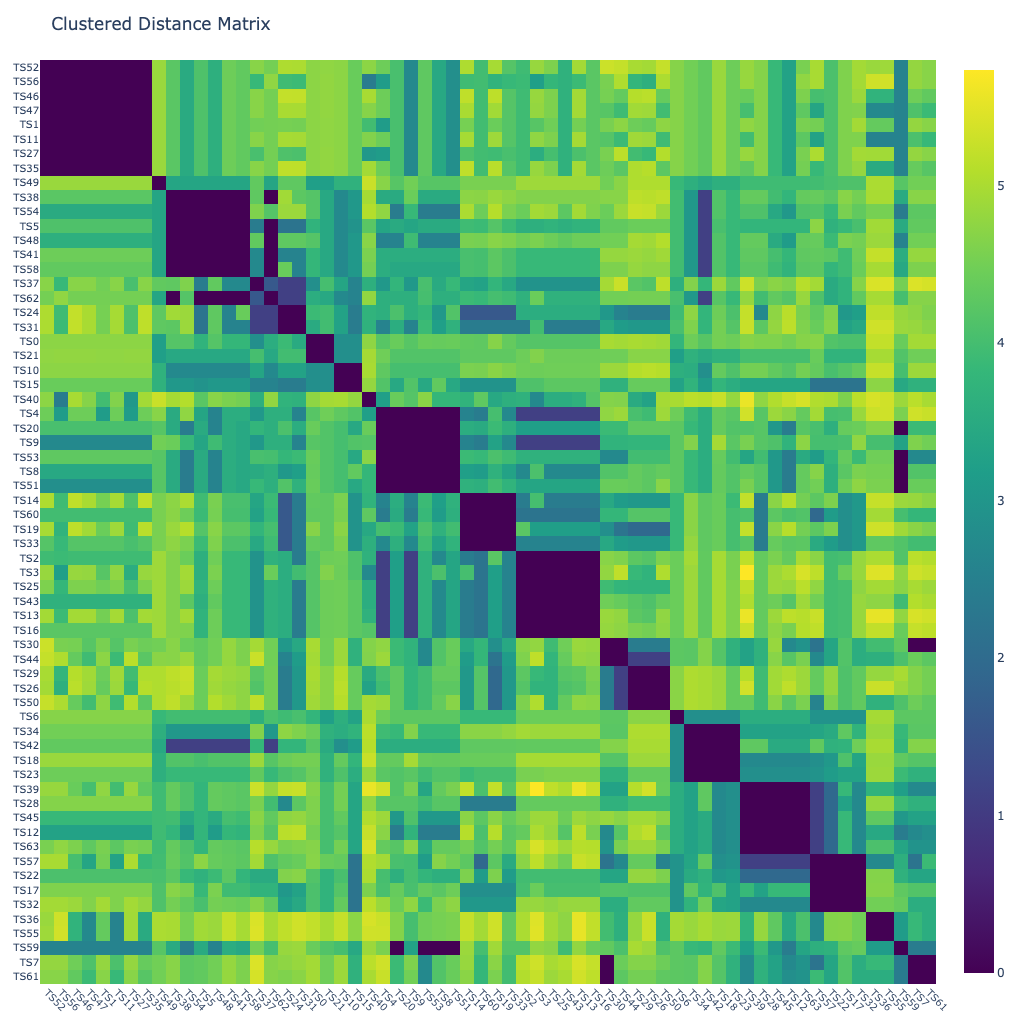

In [ ]:
#| eval: false

plot_clustered_dm_heatmap(
    Xdm,                       # data matrix (n_timeseries, n_dataframes) 
    alignment_type='fastdtw',  # 'dcor', 'fastdtw'(euclidean), 'tslearn_dtw'(euclidean), 'soft_dtw'(sqeuclidean), 'soft_dtw_div'
    dist=cosine,               # distance metric function used inside fastdtw
    radius=10,                 # refinement window size in fastdtw
    normalize='log',           # normalization method for distance matrix
    n_jobs=8,                  # number of jobs for parallelization
    base_size=16               # base pixel size
)  

::: {.callout-note title="Clustered heatmap diagnostics"}
Often the first diagnostic before running *k‑means*, *hierarchical clustering*, or *spectral clustering*:

 - Large, clean diagonal blocks → strong cluster structure
 - Fuzzy or streaky blocks → weak or overlapping clusters
 - Off‑diagonal dark regions → cross‑cluster similarities
 - Asymmetry → distance metric issues or preprocessing inconsistencies
:::

### Dendrogram
> a hierarchical tree showing how time series cluster together based on their DTW‑ or dcor‑derived distances, with merge heights reflecting the distances at which clusters join.

 [INFO] cutils.calc_dtw_dmatrix: Using cosine distance
 [DEBUG] cutils.calc_distance_matrix: Computing DTW distance matrix for symmetric data
Computing DTW distances: 100%|██████████| 2080/2080 [04:49<00:00,  7.17it/s]


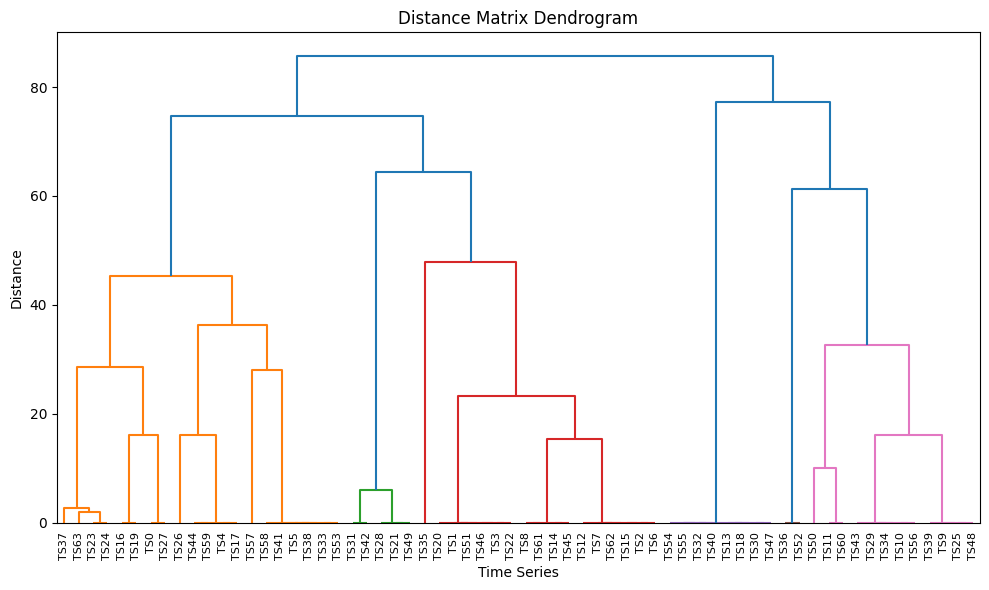

In [ ]:
#| eval: false

plot_dm_dendrogram(
    Xdm,                        # data matrix (n_timeseries, n_dataframes)
    alignment_type='fastdtw',   # Type of alignment method to use for distance computation. Options: 'dcor', 'fastdtw'(euclidean), 'tslearn_dtw'(euclidean), 'soft_dtw'(sqeuclidean), 'soft_dtw_div'
    dist=cosine,                # distance metric function to use for DTW alignment. Only applies when alignment_type='fastdtw'.
    radius=10,                  # refinement window size for FastDTW algorithm. Only applies when alignment_type='fastdtw'.
    n_jobs=8                    # number of parallel jobs to use for distance computation 
)

::: {.callout-note title="Dendrogram diagnostics"}
A dendrogram exposes the hierarchical structure of similarities among time series. It is especially useful for assessing:

- whether clusters exist at multiple resolutions
- how stable or fragile cluster boundaries are
- whether the distance metric produces coherent merges

Interpretation cues:

- Long vertical branches before merging → well‑separated clusters with strong internal cohesion
- Short branches and early merges → weak structure; time series are broadly similar or noise‑dominated
- Large jumps in merge height → natural "cut points" suggesting plausible cluster counts
- Gradual, smooth merge heights → no clear cluster boundaries; structure is diffuse
- Single long chain (ladder shape) → chaining effect; distance metric may be inappropriate or too sensitive to outliers
- Asymmetric subtree sizes → heterogeneous cluster sizes or presence of outliers
- Repeated tiny merges near the bottom → many near‑duplicates or redundant time series
:::

## Cluster Dynamics
> clustering of time series based on their DTW alignment dynamics

### Silhouette score curve diagnostics
> A silhouette score curve plots the average silhouette coefficient as a function of the number of clusters. It is a global diagnostic for selecting a meaningful cluster count and assessing whether the data contain well‑separated groups.

In [ ]:
#| eval: false

from collections import defaultdict

In [ ]:
#| eval: false

results = defaultdict(dict)

for i in [0, 200, 400, 600, 800]:       
    result =compute_silhouette_vs_k(
        emb_prj_decomp_rec1,          # the embedding object (EmbeddingCollection) that contains the time series to cluster 
        interval=(i,i+200),           # the interval of frames to cluster
        normalize=False,              # to normalize the time series before clustering (`minmax` or `meanvar`)
        metric='dtw',                 # Distance metric for clustering in K-means algorithm.
        max_k=10,                     # maximum number of clusters to evaluate 
        max_iter=10,                  # maximum number of iterations for K-means algorithm
        random_state=0,               # random state for K-means algorithm
        n_jobs=8                      # number of parallel jobs
    )
    results[i]=result                 # store results in dictionary for later plotting  

Silhouette k-scan:   0%|          | 0/9 [00:00<?, ?it/s]/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For

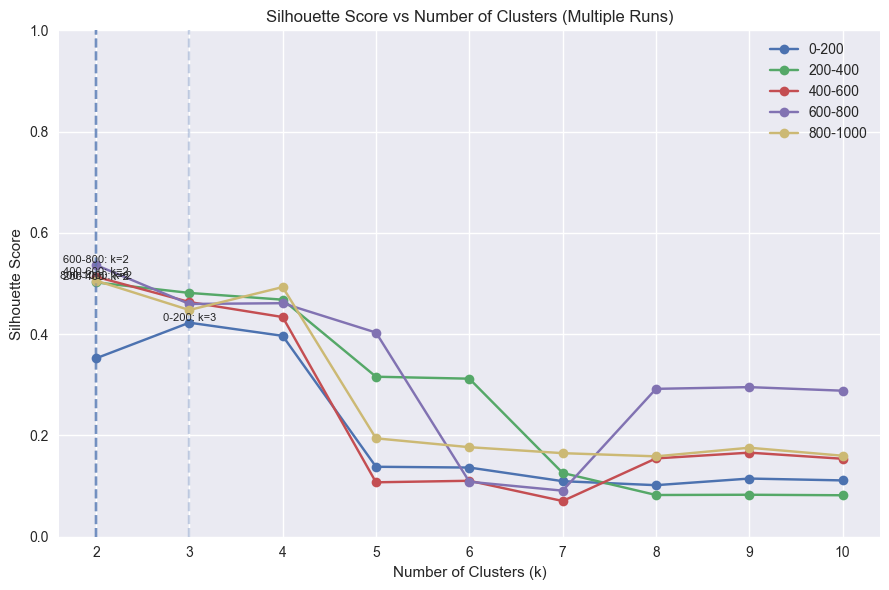

In [ ]:
#| eval: false

plot_silhouette_curves(
    results,                                                        # dictionary of silhouette results for different intervals
    labels=['0-200', '200-400', '400-600', '600-800', '800-1000'],  # labels for each interval
    show_best = True,                                               # whether to highlight the best silhouette score across intervals
    filepath='emb_prj_decomp_rec1'                                  # filepath for saving the plot  
)

::: {.callout-note title="Silhouette score curve diagnostics"}
Interpretation cues:

- A clear, sharp peak at some $k$ → strong evidence for a natural number of clusters; structure is well separated at that resolution
- A broad plateau across several $k$ → multiple clusterings are similarly valid; structure may be hierarchical or diffuse
- Monotonically decreasing curve → data likely have no meaningful cluster structure; increasing $k$ only fragments noise
- Multiple local maxima → possible multi‑scale structure; consider hierarchical clustering or domain‑driven selection
- Very low scores for all $k$ → poor separation overall; distance metric or preprocessing may be inappropriate
- Sudden drop after the peak → over‑segmentation beyond that $k$; clusters become unstable or too small
:::

::: {.callout-note title="Silhouette score magnitude diagnostics"}
The magnitude of the silhouette score reflects the overall quality of cluster separation and cohesion. It provides a global assessment of how well the data naturally partition under the chosen distance metric and clustering method.

Interpretation cues:

- 0.75–1.0 (very high) → exceptionally strong structure; clusters are compact and well separated
- 0.50–0.75 (high) → meaningful, stable clusters; good separation with minor overlap
- 0.25–0.50 (moderate) → weak or fuzzy structure; clusters exist but boundaries are not crisp
- 0.00–0.25 (low) → poor separation; clusters overlap heavily or are not meaningful
- Negative values → systematic misclassification; points fit better in neighboring clusters than their assigned one
- High variance across runs → unstable clustering; sensitive to initialization or noise
:::

### DTW based clustering
> clustering of time series based on their DTW alignment, using a K-means algorithm 

In [ ]:
#| eval: false
cluster_t = defaultdict(dict)

keys = [  
    "clusters_subj",
    "subj_clusters",
    "labels",
    "silhouette",
    "centroids",
]

for i in [0, 200, 400, 600, 800]:
    _values = dtw_clustering(
        emb_prj_decomp_rec1,         # the embedding object (EmbeddingCollection) that contains the time series to cluster
        interval=(i,i+200),          # the interval of frames to cluster
        normalize=False,             # whether to normalize the time series before clustering
        metric = "dtw",              # the distance metric for clustering
        n_clusters=4,                # the number of clusters to form
        max_iter=15,                 # the maximum number of iterations for the K-means algorithm
        random_state=0               # the random state for reproducibility
    )

    cluster_t[i] = dict(zip(keys, _values))  # store results in dictionary for later analysis and plotting

 [DEBUG] embedding.__getattr__: Accessing attribute/method 'features_tint' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'features_tint' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'subjects' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'features_tint' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'features_tint' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'features_tint' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomp

In [ ]:
#| eval: false
from nbdev_fhemb.piece_ex import dg0    # The `Piece` object that contains the original time series data and metadata for the first subject in the dataset. 
                                        # This is used for visualizing the clustered time series in the next step.

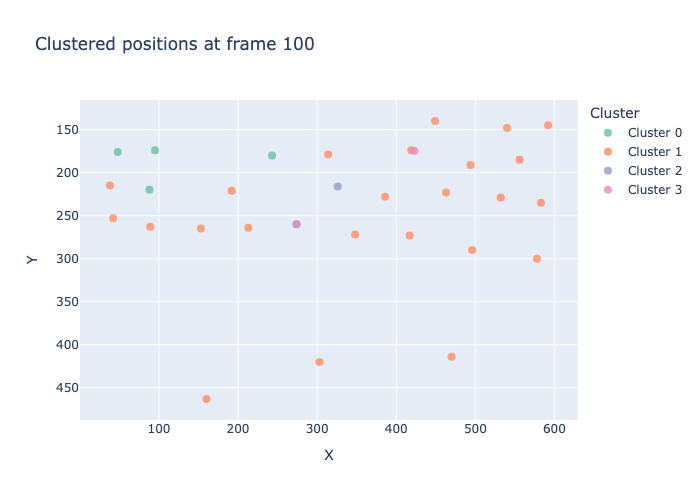

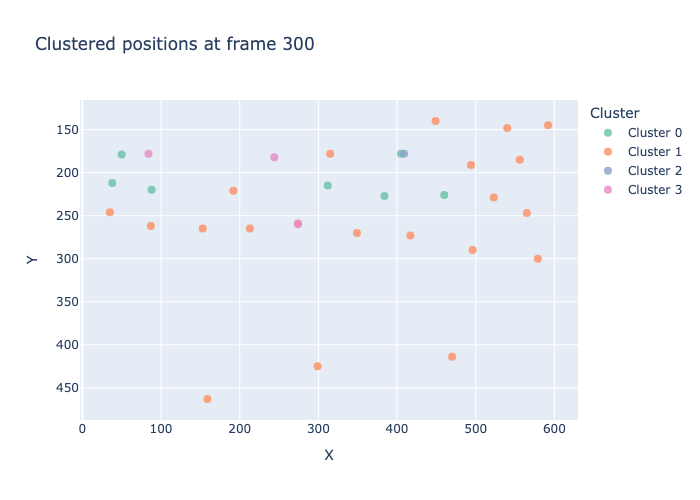

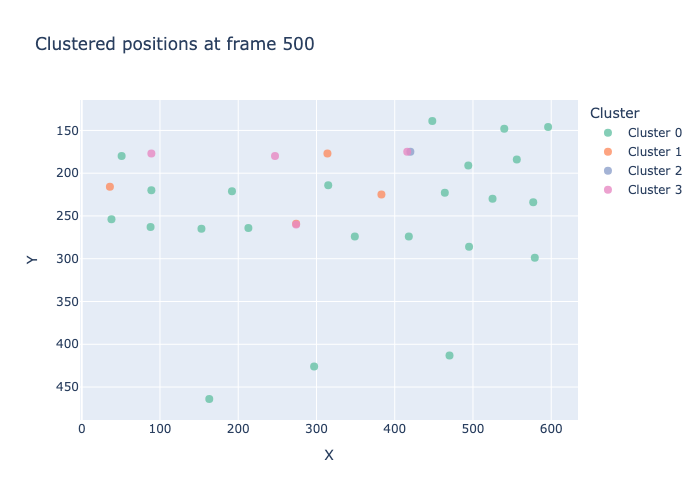

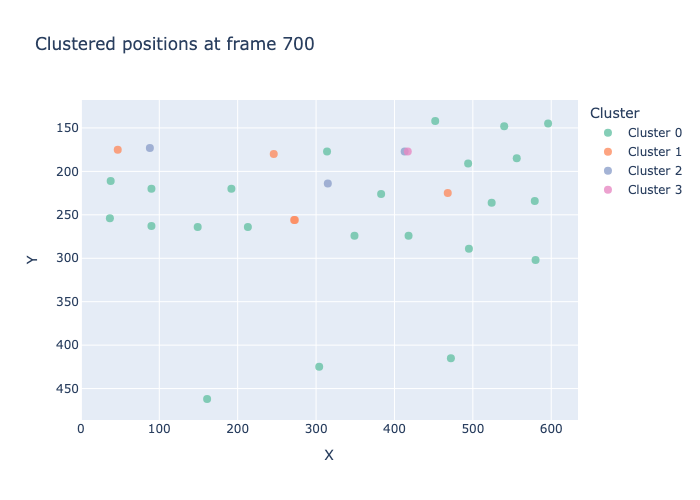

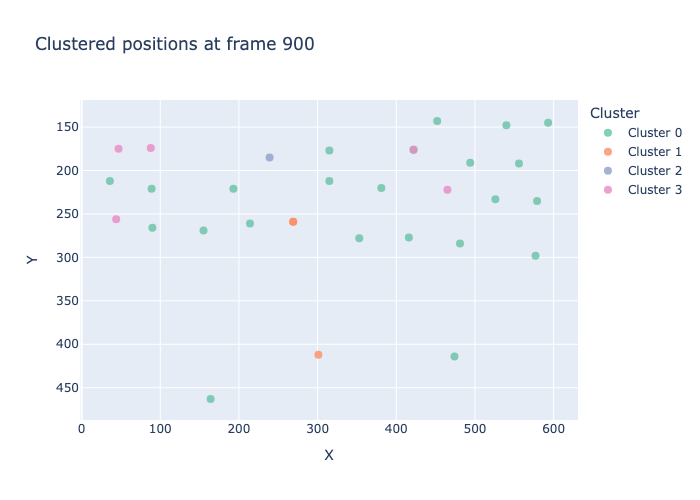

In [ ]:
#| eval: false
for frame, clusters in cluster_t.items():     # iterate over each interval and its corresponding clustering results
    depict_clusters(
        clusters['clusters_subj'],            # the cluster assignments for each time series in the interval
        dg0.face_t.position.features_tint,    # the coordinates of the subject positions corresponding to the time series
        frame=frame+100                       # the frame number to visualize (the interval center)
    )

::: {.callout-note title="DTW clustering of synchronized time series - What it shows"}
Clustering synchronized time series using DTW reveals which series share similar temporal patterns across the examined time window. Inspecting adjacent short intervals (8 sec each) helps interpret why certain series cluster together:

- **Similar interval‑by‑interval evolution**: Time series in the same cluster show comparable behavior across intervals.
- **Shared temporal structure**: Clusters reflect series that rise, fall, oscillate, or stabilize in similar ways.
- **Differences concentrated in specific intervals**: If two series diverge only in some intervals, this often explains why they fall into different clusters.
- **Distinct temporal signatures**: Outlier series show unique patterns in one or more intervals, leading to isolated cluster membership.
- **Consistent behavior**: Series with stable patterns across all intervals tend to cluster tightly.
- **Abrupt changes**: Series with internal transitions (e.g., sudden onset or decay) often cluster separately from smoother ones.
:::